# Cybercrime Trends in Canada

### Project Objective
This project analyzes police-reported cybercrime data in **Canada** from **2014 - 2024**.

The goal is to explore how cybercrime has changed over time and how it differs across provinces and territories.

### Data Source
This analysis uses publicly available data from Statistics Canada:

- [Police-reported cybercrime, number of incidents and rate per 100,000 population (Table 35-10-0002-01)](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=3510000201)

The dataset includes annual data across Canadian provinces, territories, and selected metropolitan areas.

### Key Questions
1. How have police-reported cybercrime incidents evolved in Canada over time?
2. Which provinces and territories report the highest total number of cybercrime incidents?
3. Which provinces and territories have the highest cybercrime rates per 100,000 population?
4. Which provinces and territories have experienced the fastest year-over-year (YoY) growth in cybercrime incidents?

### Notebook Content
1. **Step 1:** Install + Import Ncessary Libraries
2. **Step 2:** Reading + Exploring Data
3. **Step 3:** Data Cleaning + Preprocessing
4. **Step 4:** Data Analysis + Visualization
5. **Conclusion with Key Findings** 

## Step 1: Install + Import Necessary Libraries

In [1]:
# !pip install pandas
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

## Step 2: Reading + Exploring Data
Before analyzing the dataset, we first inspect its structure, columns, and missing values.

In [3]:
data = pd.read_csv("35100002.csv")
data.head()

,REF_DATE,GEO,DGUID,Statistics,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2014,Total police-reported cybercrime,NaN,Number of cybercrime incidents,Number,223,units,0,v116321076,1.1,15184.0,NaN,NaN,NaN,0
1,2014,Total police-reported cybercrime,NaN,"Rate per 100,000 population","Rate per 100,000 population",265,units,0,v116321077,1.2,47.7,NaN,NaN,NaN,1
2,2014,Total Non-Census metropolitan area,NaN,Number of cybercrime incidents,Number,223,units,0,v116321078,2.1,5075.0,NaN,NaN,NaN,0
3,2014,Total Non-Census metropolitan area,NaN,"Rate per 100,000 population","Rate per 100,000 population",265,units,0,v116321079,2.2,58.1,NaN,NaN,NaN,1
4,2014,Total Census metropolitan area,NaN,Number of cybercrime incidents,Number,223,units,0,v116321080,3.1,10109.0,NaN,NaN,NaN,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   REF_DATE       1240 non-null   int64  
 1   GEO            1240 non-null   str    
 2   DGUID          1156 non-null   str    
 3   Statistics     1240 non-null   str    
 4   UOM            1240 non-null   str    
 5   UOM_ID         1240 non-null   int64  
 6   SCALAR_FACTOR  1240 non-null   str    
 7   SCALAR_ID      1240 non-null   int64  
 8   VECTOR         1240 non-null   str    
 9   COORDINATE     1240 non-null   float64
 10  VALUE          1147 non-null   float64
 11  STATUS         93 non-null     str    
 12  SYMBOL         0 non-null      float64
 13  TERMINATED     0 non-null      float64
 14  DECIMALS       1240 non-null   int64  
dtypes: float64(4), int64(4), str(7)
memory usage: 145.4 KB


## Step 3 : Data Cleaning + Preprocessing
To prepare the dataset for analysis, we remove missing values in the main value column, convert values to numeric format, and drop metadata columns that are not needed for this project.

In [5]:
data.columns

Index(['REF_DATE', 'GEO', 'DGUID', 'Statistics', 'UOM', 'UOM_ID',
       'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS',
       'SYMBOL', 'TERMINATED', 'DECIMALS'],
      dtype='str')

### Step 3.1: Removing unwanted columns

In [6]:
data_clean = data.copy()

# Remove rows where VALUE is missing
data_clean = data_clean.dropna(subset=['VALUE'])

# Make sure VALUE is numeric
data_clean['VALUE'] = pd.to_numeric(data_clean['VALUE'], errors='coerce')

# Drop any rows that still have invalid VALUE entries
data_clean = data_clean.dropna(subset=['VALUE'])

# Drop columns not needed for analysis
data_clean = data_clean.drop(
    columns=['DGUID', 'SCALAR_ID', 'STATUS', 'SYMBOL', 'TERMINATED'],
    errors='ignore'
)

data_clean.columns

Index(['REF_DATE', 'GEO', 'Statistics', 'UOM', 'UOM_ID', 'SCALAR_FACTOR',
       'VECTOR', 'COORDINATE', 'VALUE', 'DECIMALS'],
      dtype='str')

### Step 3.2 : Separate Counts and Rates
The dataset includes both the total number of incidents and the rate per 100,000 population.  
To answer our questions clearly, we separate these into two datasets.

In [7]:
counts = data_clean[data_clean['Statistics'] == 'Number of cybercrime incidents'].copy()
rates = data_clean[data_clean['Statistics'] == 'Rate per 100,000 population'].copy()

### Step 3.3: Clean Region Names and Keep Comparable Geography
The `GEO` column includes province and territory names, as well as totals and some metropolitan areas.  
For this project, we focus only on provinces and territories to ensure fair comparisons.

In [8]:
counts['GEO'] = counts['GEO'].str.replace(r"\s*\[.*\]", "", regex=True)
rates['GEO'] = rates['GEO'].str.replace(r"\s*\[.*\]", "", regex=True)

In [9]:
# Remove 'total' rows
totals_to_remove = [
    'Total police-reported cybercrime',
    'Total Census metropolitan area',
    'Total Non-Census metropolitan area'
]

counts_regions = counts[~counts['GEO'].isin(totals_to_remove)].copy()
rates_regions = rates[~rates['GEO'].isin(totals_to_remove)].copy()

In [10]:
# Keep only provinces and territories
provinces = [
    'Newfoundland and Labrador',
    'Prince Edward Island',
    'Nova Scotia',
    'New Brunswick',
    'Quebec',
    'Ontario',
    'Manitoba',
    'Saskatchewan',
    'Alberta',
    'British Columbia',
    'Yukon',
    'Northwest Territories',
    'Nunavut'
]

counts_provinces = counts_regions[counts_regions['GEO'].isin(provinces)].copy()
rates_provinces = rates_regions[rates_regions['GEO'].isin(provinces)].copy()

## Step 4: Data Anlaysis + Visualization

**Note:** For clarity and readability, only the top 10 provinces and territories are displayed in the visualizations. The full dataset includes all provinces and territories.

### Question 1: How have police-reported cybercrime incidents evolved in Canada over time?

In [11]:
counts = data_clean[data_clean['Statistics'] == 'Number of cybercrime incidents'].copy()

canada_counts = counts[
    counts['GEO'].str.contains('Total police-reported cybercrime', na=False)
].copy()

canada_counts = canada_counts.sort_values('REF_DATE')

canada_table = (
    canada_counts[['REF_DATE', 'VALUE']]
    .copy()
    .rename(columns={'REF_DATE': 'Year', 'VALUE': 'Number of Incidents'})
    .sort_values(by='Year', ascending=False)
    .set_index('Year')
)

canada_table.style \
    .format({'Number of Incidents': '{:,.0f}'}) \
    .bar(color='lightblue')

,Number of Incidents
Year,
2024,"92,567"
2023,"98,252"
2022,"80,246"
2021,"71,727"
2020,"65,141"
2019,"48,318"
2018,"33,893"
2017,"27,829"
2016,"23,996"


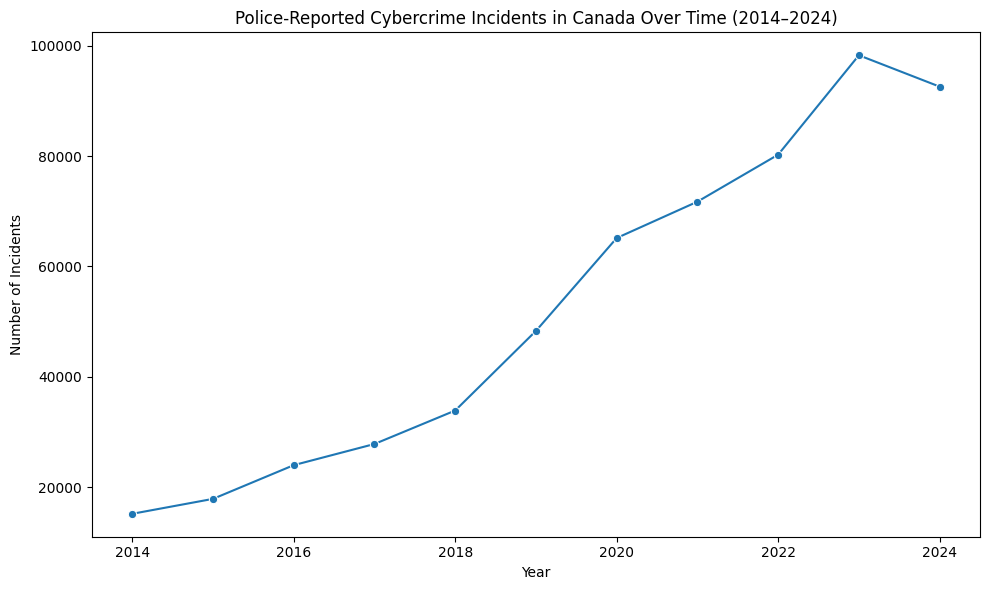

In [12]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=canada_counts,
    x='REF_DATE',
    y='VALUE',
    marker='o'
)

plt.title('Police-Reported Cybercrime Incidents in Canada Over Time (2014–2024)')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

### Insight
Cybercrime incidents in Canada show a clear upward trend over time, indicating that cyber-related offenses are becoming **more prevalent**.

This increase may reflect the growing importance of digital technologies in everyday life, along with improved reporting and detection of cybercrime. Sharp increases in later years may also be associated with shifts in online activity, including the expansion of digital services during and after the COVID-19 period.

### Question 2: Which provinces and territories report the highest total number of cybercrime incidents?

In [13]:
region_totals = (
    counts_provinces.groupby('GEO')['VALUE']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_regions = (
    region_totals
    .to_frame(name='Total Incidents')
    .rename_axis('Province / Territory')
)

top_regions.style \
    .format({'Total Incidents': '{:,.0f}'}) \
    .bar(color='lightblue') \
    .set_caption('Top Provinces and Territories by Total Cybercrime Incidents (2014–2024)')

,Total Incidents
Province / Territory,
Ontario,"213,250"
British Columbia,"136,905"
Alberta,"77,025"
Quebec,"64,083"
Nova Scotia,"26,812"
Manitoba,"16,164"
Saskatchewan,"15,772"
New Brunswick,"13,833"
Newfoundland and Labrador,"7,013"


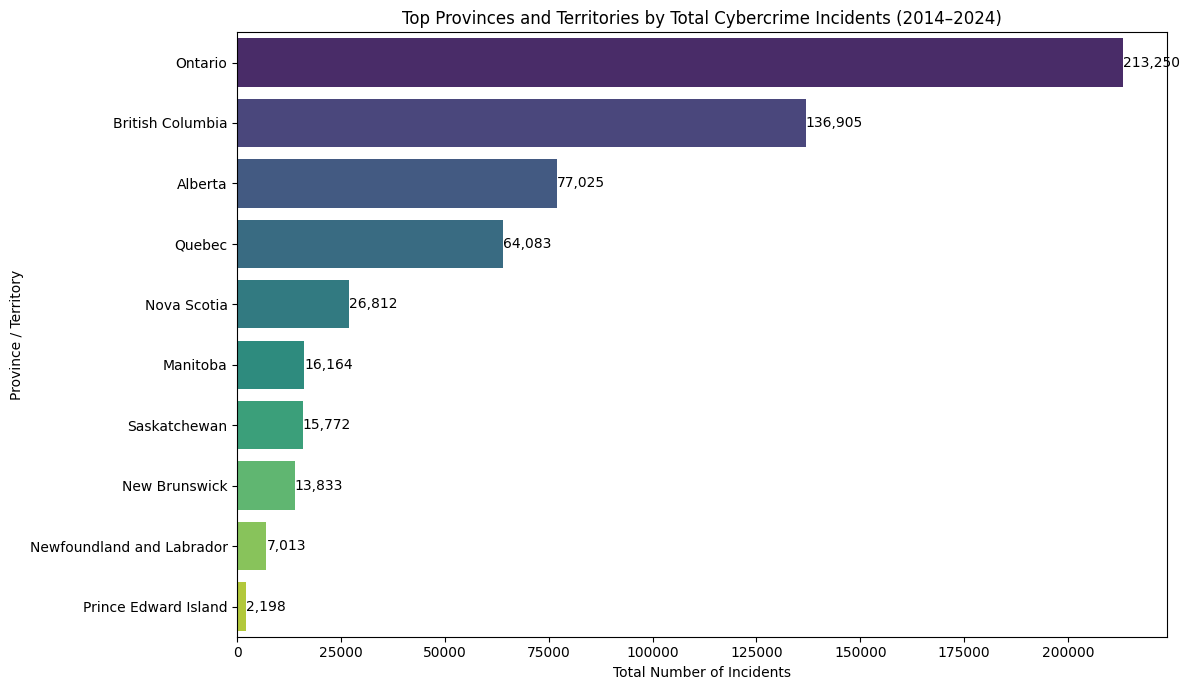

In [14]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=region_totals.values,
    y=region_totals.index,
    hue=region_totals.index,
    palette='viridis',
    legend=False
)

plt.title('Top Provinces and Territories by Total Cybercrime Incidents (2014–2024)')
plt.xlabel('Total Number of Incidents')
plt.ylabel('Province / Territory')

for i, v in enumerate(region_totals.values):
    plt.text(v, i, f"{int(v):,}", va='center')

plt.tight_layout()
plt.show()

### Insight
The results show that provinces such as **Ontario** and **British Columbia** report the **highest total** number of cybercrime incidents. This is expected, as these regions have larger populations.

However, higher total counts do not necessarily imply a higher relative risk of cybercrime. Larger populations naturally generate more reported incidents, which is why it is important to also examine population-adjusted rates.

### Question 3: Which provinces and territories have the highest cybercrime rates per 100,000 population?

In [15]:
top_rates = (
    rates_provinces.groupby('GEO')['VALUE']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_rates_table = (
    top_rates
    .to_frame(name='Average Rate per 100,000')
    .rename_axis('Province / Territory')
)

top_rates_table.style \
    .format({'Average Rate per 100,000': '{:.1f}'}) \
    .bar(color='lightblue') \
    .set_caption('Top Provinces and Territories by Average Cybercrime Rate per 100,000 Population (2014–2024)')

,"Average Rate per 100,000"
Province / Territory,
Nova Scotia,243.8
British Columbia,235.5
New Brunswick,167.2
Alberta,161.5
Yukon,152.5
Northwest Territories,138.8
Ontario,133.5
Saskatchewan,123.0
Prince Edward Island,122.4


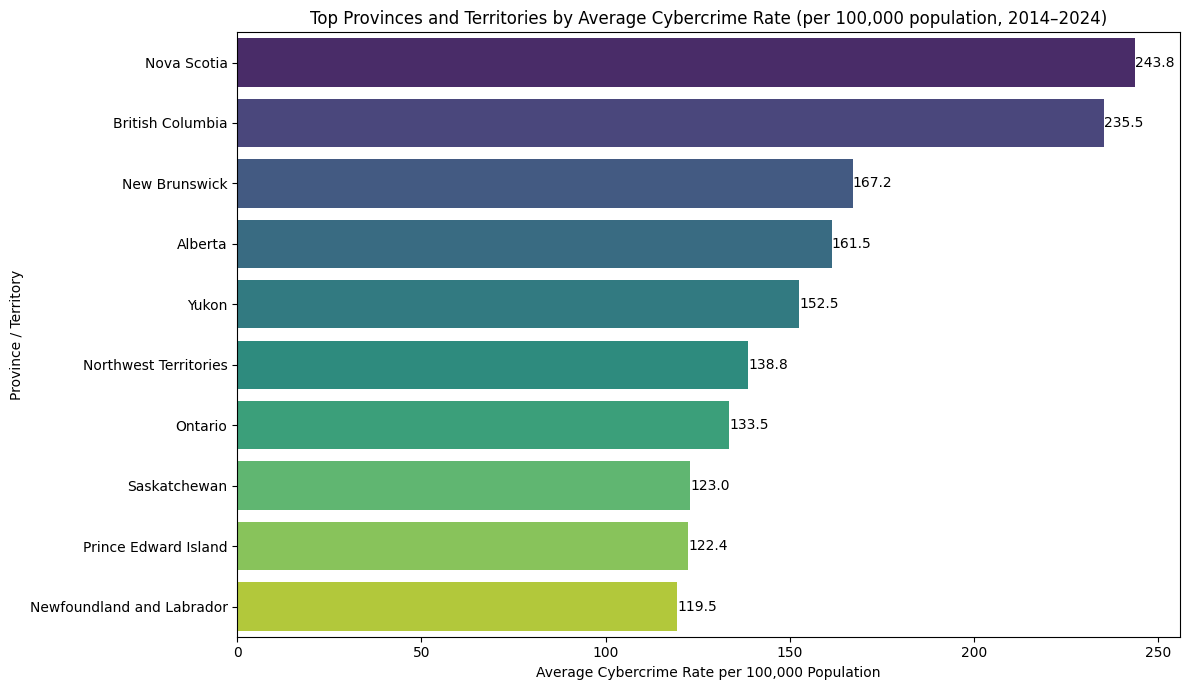

In [16]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_rates.values,
    y=top_rates.index,
    hue=top_rates.index,
    palette='viridis',
    legend=False
)

plt.title('Top Provinces and Territories by Average Cybercrime Rate (per 100,000 population, 2014–2024)')
plt.xlabel('Average Cybercrime Rate per 100,000 Population')
plt.ylabel('Province / Territory')

for i, v in enumerate(top_rates.values):
    plt.text(v, i, f"{v:.1f}", va='center')

plt.tight_layout()
plt.show()

### Insight
When comparing cybercrime rates per 100,000 population, the ranking changes noticeably compared to total incident counts.

While larger provinces dominate in total incidents, smaller provinces and territories may have higher rates, indicating a **greater relative burden** of cybercrime on their populations.

This highlights the importance of using normalized metrics when comparing regions, since raw counts alone can be misleading.

### Question 4: Which provinces and territories have experienced the fastest year-over-year (YoY) growth in cybercrime incidents?

In [17]:
growth_table = counts_provinces.pivot_table(
    index='GEO',
    columns='REF_DATE',
    values='VALUE',
    aggfunc='sum'
)

growth_pct = growth_table.pct_change(axis=1)

avg_growth = growth_pct.mean(axis=1)

avg_growth_pct = (avg_growth * 100).sort_values(ascending=False)

growth_table_styled = (
    avg_growth_pct.head(10)
    .to_frame(name='Average YoY Growth (%)')
    .rename_axis('Province / Territory')
)

growth_table_styled.style \
    .format({'Average YoY Growth (%)': '{:.1f}%'}) \
    .bar(color='lightblue') \
    .set_caption('Top Provinces and Territories by Average Year-over-Year Cybercrime Growth (2014–2024)')

,Average YoY Growth (%)
Province / Territory,
Nunavut,31.5%
Northwest Territories,31.2%
Manitoba,28.1%
Alberta,24.8%
British Columbia,23.6%
Newfoundland and Labrador,22.4%
Ontario,21.0%
Quebec,19.7%
Prince Edward Island,18.9%


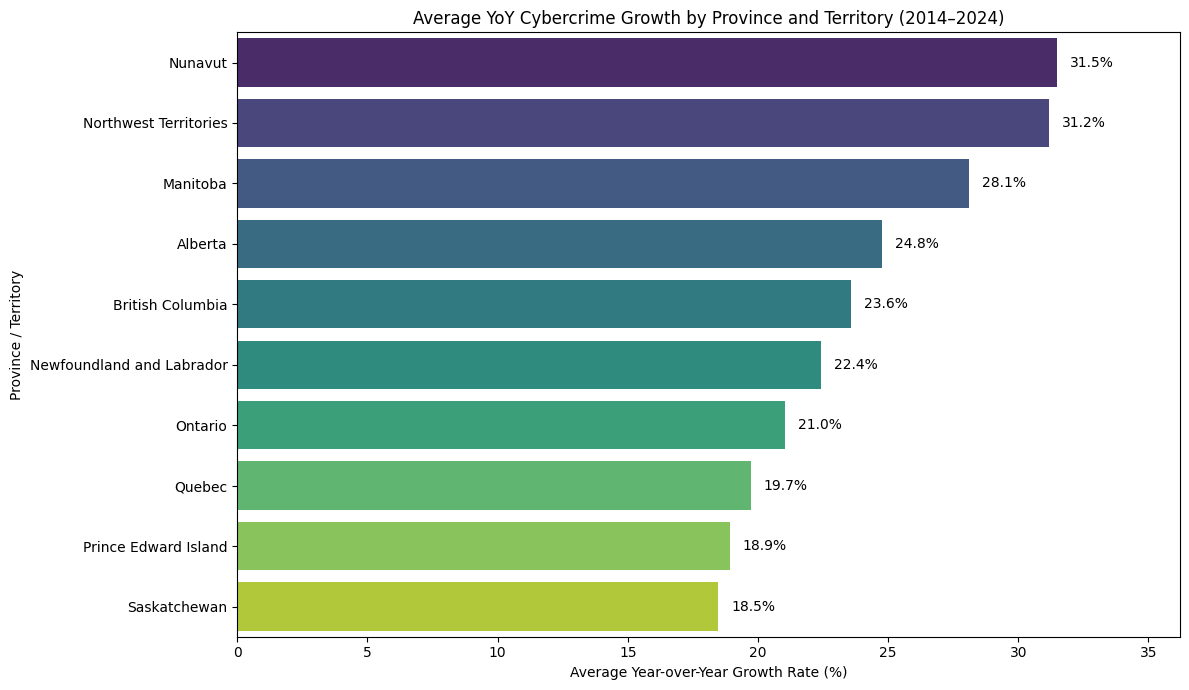

In [18]:
top_growth = avg_growth_pct.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_growth.values,
    y=top_growth.index,
    hue=top_growth.index,
    palette='viridis',
    legend=False
)

plt.title('Average YoY Cybercrime Growth by Province and Territory (2014–2024)')
plt.xlabel('Average Year-over-Year Growth Rate (%)')
plt.ylabel('Province / Territory')

for i, v in enumerate(top_growth.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.xlim(0, top_growth.max() * 1.15)

plt.tight_layout()
plt.show()

### Insight
This analysis examines the average year-over-year (YoY) growth in cybercrime incidents across provinces and territories over the period 2014–2024.

While some regions may not have the highest total number of incidents, they can still show relatively high YoY growth rates. This suggests that **cybercrime is increasing more rapidly** in these areas, potentially indicating emerging challenges.

However, higher growth rates should be interpreted with caution, especially in smaller provinces and territories, where lower baseline values can produce larger percentage changes.

Overall, analyzing YoY growth helps identify regions where cybercrime is accelerating, providing useful insight for prevention and policy planning.

## Conclusion

This project analyzed police-reported cybercrime trends in **Canada** using **Statistics Canada** data.

### Key Findings
- Cybercrime incidents in Canada have generally **increased** over time.
- Provinces with larger populations report higher total numbers of incidents.
- Population-adjusted rates reveal that some smaller regions experience a **disproportionately high** cybercrime burden.
- YoY growth analysis helps identify regions where cybercrime is increasing most rapidly.

Overall, combining trend analysis, geographic comparison, normalized rates, and YoY growth patterns provides a more complete understanding of cybercrime in Canada.